## Import Libraries

In [33]:
# Basic Data Handling Libraries
import pandas as pd              # For data manipulation and analysis
import numpy as np               # For numerical operations
import re                        # For regular expressions (text cleaning)

# 
# Visualization Libraries
import matplotlib.pyplot as plt  
import seaborn as sns            
%matplotlib inline               

# Utility Libraries
import pickle                    # For saving and loading Python objects
import time                      # For measuring execution time

# NLTK Libraries for Text Processing
from nltk.tokenize import TweetTokenizer  # Tokenizer for social media text
import nltk

from nltk import Text                      # Text object for NLP operations
from nltk.tokenize import regexp_tokenize  # Tokenization using regex patterns
from nltk.tokenize import word_tokenize    # Word-level tokenization
from nltk.tokenize import sent_tokenize    # Sentence-level tokenization
from nltk.stem import WordNetLemmatizer    # Lemmatization (convert words to base form)
from nltk.stem import PorterStemmer        # Stemming (reduce words to root form)
from nltk.corpus import stopwords          # Stopwords list (common words)

# Feature Extraction (Text Vectorization)
from sklearn.feature_extraction.text import CountVectorizer  # Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF representation

# Machine Learning Models
from sklearn.linear_model import LogisticRegression          # Logistic Regression model
from sklearn.naive_bayes import MultinomialNB                # Naive Bayes for text data
from sklearn.multiclass import OneVsRestClassifier           # For multi-label classification

# Model Training & Evaluation
from sklearn.model_selection import train_test_split         # Split data into train/test
from sklearn.model_selection import cross_val_score          # Cross-validation
from sklearn.model_selection import GridSearchCV              # Hyperparameter tuning

from sklearn import metrics                                  # General ML metrics
from sklearn.metrics import classification_report            # Precision, recall, F1-score
from sklearn.metrics import confusion_matrix                 # Confusion matrix


# Pipeline
from sklearn.pipeline import make_pipeline                   # Combine vectorizer + model


## CountVectorizer
This example shows how to convert text into a **Bag of Words** using `CountVectorizer`.  
Unigrams and bigrams are created, rare and very common words are filtered using `min_df` and `max_df`, and the number of features is limited.

In [34]:
# Sample text data
txt = [
    "He is ::having a great Time, at the park time?",
    "She, unlike most women, is a big player on the park's grass.",
    "she can't be going"
]

# Initialize CountVectorizer
# - stop_words='english' removes common English words (is, the, at, etc.)
# - analyzer='word' means tokenization is done at word level
# - ngram_range=(1,1) means only unigrams (single words)
# - min_df=1 keeps words appearing at least once
# - max_df=1.0 keeps words appearing in up to 100% of documents
# - max_features=None means keep all features
count_vec = CountVectorizer(
    stop_words='english',
    analyzer='word',
    ngram_range=(1, 1),
    min_df=1,
    max_df=1.0,
    max_features=None
)

# Learn the vocabulary from the text data
# fit() builds the vocabulary and learns word frequencies
count_vec.fit(txt)

# Transform the text data into Bag of Words representation
# Each row represents a document
# Each column represents a word count
bag_of_words = count_vec.transform(txt)

# Display the feature (word) names learned by CountVectorizer
count_vec.get_feature_names_out()


array(['big', 'going', 'grass', 'great', 'having', 'park', 'player',
       'time', 'unlike', 'women'], dtype=object)

In [35]:
print("Vocabulary Count: {}".format(len(count_vec.vocabulary_)))
print("Vocabulary: \n", count_vec.vocabulary_)

Vocabulary Count: 10
Vocabulary: 
 {'having': 4, 'great': 3, 'time': 7, 'park': 5, 'unlike': 8, 'women': 9, 'big': 0, 'player': 6, 'grass': 2, 'going': 1}


### N-grams N = 2

In [36]:
# Initialize CountVectorizer with unigrams and bigrams
count_vec = CountVectorizer(
    stop_words="english",
    analyzer="word",
    ngram_range=(1, 2),
    max_df=1.0,
    min_df=1,
    max_features=None
)

# Fit the vectorizer on text data
count_vec.fit(txt)

# Convert text into Bag of Words representation
bag_of_words = count_vec.transform(txt)

# Print vocabulary (unigrams + bigrams)
print(count_vec.get_feature_names_out())


['big' 'big player' 'going' 'grass' 'great' 'great time' 'having'
 'having great' 'park' 'park grass' 'park time' 'player' 'player park'
 'time' 'time park' 'unlike' 'unlike women' 'women' 'women big']


### Min_df, Max_df, Max_features

In [37]:
# CountVectorizer with frequency filtering and feature limit
count_vec = CountVectorizer(
    stop_words="english",
    analyzer="word",
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=0.3,
    max_features=5
)

# Learn vocabulary from text
count_vec.fit(txt)

# Convert text to bag-of-words
bag_of_words = count_vec.transform(txt)

# Show selected features
print(count_vec.get_feature_names_out())


['big' 'park' 'time' 'unlike' 'unlike women']


## TF-IDF Vectorizer
TF-IDF converts text into numerical features by giving **higher weight to important words** and **lower weight to very common words**.  
It helps models focus on words that better describe a document.

In [38]:
# Sample text data
txt1 = [
    'His smile was not perfect',
    'His smile was not not not not perfect',
    'she not sang'
]

# Initialize TF-IDF Vectorizer
# No smoothing, no sublinear scaling, and no normalization
tf = TfidfVectorizer(
    smooth_idf=False,
    sublinear_tf=False,
    norm=None,
    analyzer='word'
)

# Learn vocabulary and IDF values
tf.fit(txt1)

# Transform text into TF-IDF matrix
txt_transformed = tf.transform(txt1)

# Display vocabulary learned by the vectorizer
tf.vocabulary_


{'his': 0, 'smile': 5, 'was': 6, 'not': 1, 'perfect': 2, 'she': 4, 'sang': 3}

In [39]:
idf = tf.idf_
print(dict(zip(tf.get_feature_names_out(), idf)))

{'his': 1.4054651081081644, 'not': 1.0, 'perfect': 1.4054651081081644, 'sang': 2.09861228866811, 'she': 2.09861228866811, 'smile': 1.4054651081081644, 'was': 1.4054651081081644}


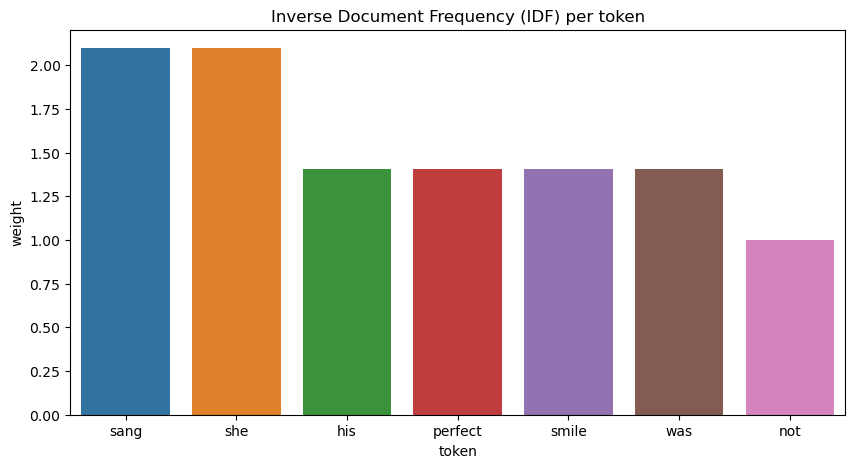

In [40]:
# Map tokens to their IDF weights
rr = dict(zip(tf.get_feature_names_out(), idf))

# Create DataFrame for visualization
token_weight = pd.DataFrame.from_dict(rr, orient='index').reset_index()
token_weight.columns = ('token', 'weight')

# Sort tokens by IDF weight
token_weight = token_weight.sort_values(by='weight', ascending=False)
token_weight

# Plot IDF values
sns.barplot(x='token', y='weight', data=token_weight)
plt.title("Inverse Document Frequency (IDF) per token")

fig = plt.gcf()
fig.set_size_inches(10, 5)
plt.show()


In [41]:
feature_names = np.array(tf.get_feature_names_out())
sorted_by_idf = np.argsort(tf.idf_)
print("Features with lowest idf:\n{}".format(
       feature_names[sorted_by_idf[:3]]))
print("\nFeatures with highest idf:\n{}".format(
       feature_names[sorted_by_idf[-3:]]))

Features with lowest idf:
['not' 'his' 'perfect']

Features with highest idf:
['was' 'sang' 'she']


In [42]:
txt_transformed.toarray()[1]

array([1.40546511, 4.        , 1.40546511, 0.        , 0.        ,
       1.40546511, 1.40546511])

In [43]:
# find maximum value for each of the features over all of dataset:
max_val = txt_transformed.max(axis=0).toarray().ravel()

# sort weights from smallest to biggest and extract their indices 
sort_by_tfidf = max_val.argsort()

print("Features with lowest tfidf:\n{}".format(
      feature_names[sort_by_tfidf[:3]]))

print("\nFeatures with highest tfidf: \n{}".format(
      feature_names[sort_by_tfidf[-3:]]))

Features with lowest tfidf:
['his' 'perfect' 'smile']

Features with highest tfidf: 
['sang' 'she' 'not']


## Load, Clean, Train, Vectorize, Classify Toxic Comments (w/o parameter tuning)

In [44]:
# Load Data
train = pd.read_csv(r'toxic-comment-classification-data/train.csv.zip')
holdout = pd.read_csv(r'toxic-comment-classification-data/test.csv.zip').fillna(' ')

In [45]:
# print first 10 rows of training data
train.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [46]:
# unique value counts of 'toxic' column
train['toxic'].value_counts()

0    144277
1     15294
Name: toxic, dtype: int64

In [47]:
train['identity_hate'].value_counts()

0    158166
1      1405
Name: identity_hate, dtype: int64

### Clean Text Data

In [48]:
# we will only clean \\n's, Username, IP and http links

train['comment_text'] = train['comment_text'].map(lambda x: re.sub(r'\\n', ' ', str(x)))
train['comment_text'] = train['comment_text'].map(lambda x: re.sub("\[\[User.*",'',str(x)))
train['comment_text'] = train['comment_text'].map(lambda x: re.sub("\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}",'',str(x)))
train['comment_text'] = train['comment_text'].map(lambda x: re.sub("(http://.*?\s)|(http://.*)",'',str(x)))


In [49]:
# do the same for holdout set
holdout['comment_text'] = holdout['comment_text'].map(lambda x: re.sub('\\n',' ',str(x)))
holdout['comment_text'] = holdout['comment_text'].map(lambda x: re.sub("\[\[User.*",'',str(x)))
holdout['comment_text'] = holdout['comment_text'].map(lambda x: re.sub("\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}",'',str(x)))
holdout['comment_text'] = holdout['comment_text'].map(lambda x: re.sub("(http://.*?\s)|(http://.*)",'',str(x)))

In [50]:
x = train['comment_text']
y = train.iloc[:, 2:8]

### Train-Test Split

In [51]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=13)

In [52]:
# size of train and test sets
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(127656,)
(127656, 6)
(31915,)
(31915, 6)


### Vectorize

In [53]:
# Instantiate the vectorizer
word_vectorizer = TfidfVectorizer(
    stop_words='english',
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{2,}',  #vectorize 2-character words or more
    ngram_range=(1, 1),
    max_features=30000)

# fit and transform on it the training features
word_vectorizer.fit(X_train)
X_train_word_features = word_vectorizer.transform(X_train)

#transform the test features to sparse matrix
test_features = word_vectorizer.transform(X_test)

# transform the holdout text for submission at the end
holdout_text = holdout['comment_text']
holdout_word_features = word_vectorizer.transform(holdout_text)

## Logistic Regression

In [54]:
# Target labels for multi-label classification
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

losses = []
auc = []

for class_name in class_names:
    # Select one label at a time
    train_target = y_train[class_name]
    test_target = y_test[class_name]
    
    # Logistic Regression classifier
    classifier = LogisticRegression(solver='sag', C=10)

    # Cross-validated log loss
    cv_loss = np.mean(
        cross_val_score(classifier, X_train_word_features, train_target,
                        cv=5, scoring='neg_log_loss')
    )
    losses.append(cv_loss)
    print(f'CV Log_loss score for class {class_name} is {cv_loss}')

    # Cross-validated accuracy
    cv_score = np.mean(
        cross_val_score(classifier, X_train_word_features, train_target,
                        cv=5, scoring='accuracy')
    )
    print(f'CV Accuracy score for class {class_name} is {cv_score}')
    
    # Train model on full training data
    classifier.fit(X_train_word_features, train_target)
    
    # Predictions
    y_pred = classifier.predict(test_features)
    y_pred_prob = classifier.predict_proba(test_features)[:, 1]
    
    # ROC-AUC score
    auc_score = metrics.roc_auc_score(test_target, y_pred_prob)
    auc.append(auc_score)
    print(f"CV ROC_AUC score {auc_score}\n")
    
    # Evaluation reports
    print(confusion_matrix(test_target, y_pred))
    print(classification_report(test_target, y_pred))

# Overall performance
print(f'Total average CV Log_loss score is {np.mean(losses)}')
print(f'Total average CV ROC_AUC score is {np.mean(auc)}')


CV Log_loss score for class toxic is -0.1157448696595375
CV Accuracy score for class toxic is 0.9590931887302755
CV ROC_AUC score 0.9654993604590867

[[28572   355]
 [  968  2020]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28927
           1       0.85      0.68      0.75      2988

    accuracy                           0.96     31915
   macro avg       0.91      0.83      0.87     31915
weighted avg       0.96      0.96      0.96     31915

CV Log_loss score for class severe_toxic is -0.028708214683358397
CV Accuracy score for class severe_toxic is 0.9902080603838485
CV ROC_AUC score 0.9820396043780009

[[31533    79]
 [  214    89]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31612
           1       0.53      0.29      0.38       303

    accuracy                           0.99     31915
   macro avg       0.76      0.65      0.69     31915
weighted avg       0.99

### Parameter Tunning

In [55]:
# Pipeline: TF-IDF + One-vs-Rest Logistic Regression
pipe = make_pipeline(
    TfidfVectorizer(
        stop_words='english',
        strip_accents='unicode',
        token_pattern=r'\w{1,}',   # allow tokens with 1+ characters
        analyzer='word',
        ngram_range=(1, 1),
        min_df=5
    ),
    OneVsRestClassifier(LogisticRegression())
)

# Parameters to tune
param_grid = {
    'tfidfvectorizer__max_features': [10000, 30000],
    'onevsrestclassifier__estimator__solver': ['liblinear', 'sag'],
}

# Grid search with ROC-AUC scoring
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='roc_auc')

# Fit grid search
grid3 = grid.fit(X_train, y_train)


### Analysis

In [56]:
print(grid3.best_estimator_.named_steps['onevsrestclassifier'])
print(grid3.best_estimator_.named_steps['tfidfvectorizer'])

OneVsRestClassifier(estimator=LogisticRegression(solver='sag'))
TfidfVectorizer(max_features=30000, min_df=5, stop_words='english',
                strip_accents='unicode', token_pattern='\\w{1,}')


In [57]:
grid3.best_params_

{'onevsrestclassifier__estimator__solver': 'sag',
 'tfidfvectorizer__max_features': 30000}

In [58]:
predicted_y_test = grid3.predict(X_test)

In [59]:
print("Toxic Confusion Matrixs: \n{}".format(confusion_matrix(y_test['toxic'], predicted_y_test[:,0])))
print("\nSevere Toxic: \n{}".format(confusion_matrix(y_test['severe_toxic'], predicted_y_test[:,1])))
print("\nObscene: \n{}".format(confusion_matrix(y_test['obscene'], predicted_y_test[:,2])))
print("\nThreat: \n{}".format(confusion_matrix(y_test['threat'], predicted_y_test[:,3])))
print("\nInsult: \n{}".format(confusion_matrix(y_test['insult'], predicted_y_test[:,4])))
print("\nIdentity Hate: \n{}".format(confusion_matrix(y_test['identity_hate'], predicted_y_test[:,5])))

print("\nToxic Classification report: \n{}".format(classification_report(y_test['toxic'], predicted_y_test[:,0])))
print("\nSevere Toxic: \n{}".format(classification_report(y_test['severe_toxic'], predicted_y_test[:,1])))
print("\nObscene: \n{}".format(classification_report(y_test['obscene'], predicted_y_test[:,2])))
print("\nThreat: \n{}".format(classification_report(y_test['threat'], predicted_y_test[:,3])))
print("\nInsult: \n{}".format(classification_report(y_test['insult'], predicted_y_test[:,4])))
print("\nIdentity Hate: \n{}".format(classification_report(y_test['identity_hate'], predicted_y_test[:,5])))

Toxic Confusion Matrixs: 
[[28766   161]
 [ 1234  1754]]

Severe Toxic: 
[[31558    54]
 [  235    68]]

Obscene: 
[[30209    82]
 [  598  1026]]

Threat: 
[[31815    10]
 [   76    14]]

Insult: 
[[30236   176]
 [  755   748]]

Identity Hate: 
[[31617    21]
 [  233    44]]

Toxic Classification report: 
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28927
           1       0.92      0.59      0.72      2988

    accuracy                           0.96     31915
   macro avg       0.94      0.79      0.85     31915
weighted avg       0.95      0.96      0.95     31915


Severe Toxic: 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31612
           1       0.56      0.22      0.32       303

    accuracy                           0.99     31915
   macro avg       0.77      0.61      0.66     31915
weighted avg       0.99      0.99      0.99     31915


Obscene: 
            

In [60]:
vectorizer = grid3.best_estimator_.named_steps["tfidfvectorizer"]
# transform the training dataset:
X_test_set = vectorizer.transform(X_test)


# find maximum value for each of the features over dataset:
max_value = X_test_set.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()

# get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

print("Features with lowest tfidf:\n{}".format(
      feature_names[sorted_by_tfidf[:20]]))

print("\nFeatures with highest tfidf: \n{}".format(
      feature_names[sorted_by_tfidf[-20:]]))

Features with lowest tfidf:
['kaczynski' 'thnaks' 'mondays' 'copernicus' 'monger' 'thong' 'thorne'
 'thoth' 'copypasted' 'coop' 'coolest' 'cooks' 'thracians' 'threaded'
 'conway' 'moniter' 'queues' 'coolie' 'threatning' 'monarchical']

Features with highest tfidf: 
['pwned' 'fixed' 'maybe' 'retarded' 'need' 'stab' 'nazi' 'articles'
 'article' 'natural' 'famous' 'expire' 'fag' 'faggot' 'falafel' 'names'
 'recommendation' 'way' 'explain' 'speech']


## Adding Feature

In [61]:
# calculate lenght of characters in each comment
train['len_character'] = train['comment_text'].apply(lambda x: len(re.findall(r"[\w]", str(x))))

In [62]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import FeatureUnion #unites all arrays into one array
from sklearn.pipeline import Pipeline

In [63]:
x = train[['comment_text','len_character']] #these will be our features
y = train.iloc[:, 2:8]  
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=13)

In [64]:
# Preprocess the numeric data: get_numeric_data
get_numeric_data = FunctionTransformer(lambda a: a[['len_character']], validate=False)
get_text_data = FunctionTransformer(lambda a: a['comment_text'], validate=False)

print(get_text_data.fit_transform(X_train).shape)
print(get_numeric_data.fit_transform(X_train).shape)

(127656,)
(127656, 1)


In [65]:
pl = Pipeline([
        ('union', FeatureUnion(                      # unites both text and numeric arrays into one array
            transformer_list = [
                ('numeric_features', Pipeline([
                    ('selector', get_numeric_data)
                ])),
                ('text_features', Pipeline([
                    ('selector', get_text_data),
                    ('vectorizer', TfidfVectorizer(
                                                    stop_words='english',
                                                    strip_accents='unicode',
                                                    token_pattern=r'\w{2,}',
                                                    analyzer='word',
                                                    ngram_range=(1, 1),
                                                    min_df=5))
                ]))
             ]
        )), # right here is where we would put interaction terms preprocessing such as PolynomialFeatures
            # right here is where we would put a scaler if we needed one
        ('clf', OneVsRestClassifier(LogisticRegression())) 
    ])

In [66]:
param_grid = {'union__text_features__vectorizer__max_features': [10000, 30000],
              'clf__estimator__C': [0.1, 1]
             } 
grid = GridSearchCV(pl, param_grid, cv=3, scoring='roc_auc')

grid4 = grid.fit(X_train, y_train)

c:\Users\Himanshu Soam\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Himanshu Soam\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

In [67]:
print(grid4.best_score_)
print(grid4.best_params_)
print(grid4.estimator)

0.975089606383825
{'clf__estimator__C': 1, 'union__text_features__vectorizer__max_features': 30000}
Pipeline(steps=[('union',
                 FeatureUnion(transformer_list=[('numeric_features',
                                                 Pipeline(steps=[('selector',
                                                                  FunctionTransformer(func=<function <lambda> at 0x000001BFE722B790>))])),
                                                ('text_features',
                                                 Pipeline(steps=[('selector',
                                                                  FunctionTransformer(func=<function <lambda> at 0x000001BFE722B040>)),
                                                                 ('vectorizer',
                                                                  TfidfVectorizer(min_df=5,
                                                                                  stop_words='english',
                                

In [68]:
pred_y_test = grid4.predict(X_test)

print("Toxic Confusion Matrixs: \n{}".format(confusion_matrix(y_test['toxic'], pred_y_test[:,0])))
print("\nSevere Toxic: \n{}".format(confusion_matrix(y_test['severe_toxic'], pred_y_test[:,1])))
print("\nObscene: \n{}".format(confusion_matrix(y_test['obscene'], pred_y_test[:,2])))
print("\nThreat: \n{}".format(confusion_matrix(y_test['threat'], pred_y_test[:,3])))
print("\nInsult: \n{}".format(confusion_matrix(y_test['insult'], pred_y_test[:,4])))
print("\nIdentity Hate: \n{}".format(confusion_matrix(y_test['identity_hate'], pred_y_test[:,5])))

print("\nToxic Classification report: \n{}".format(classification_report(y_test['toxic'], pred_y_test[:,0])))
print("\nSevere Toxic: \n{}".format(classification_report(y_test['severe_toxic'], pred_y_test[:,1])))
print("\nObscene: \n{}".format(classification_report(y_test['obscene'], pred_y_test[:,2])))
print("\nThreat: \n{}".format(classification_report(y_test['threat'], pred_y_test[:,3])))
print("\nInsult: \n{}".format(classification_report(y_test['insult'], pred_y_test[:,4])))
print("\nIdentity Hate: \n{}".format(classification_report(y_test['identity_hate'], pred_y_test[:,5])))

Toxic Confusion Matrixs: 
[[28762   165]
 [ 1298  1690]]

Severe Toxic: 
[[31543    69]
 [  228    75]]

Obscene: 
[[30189   102]
 [  610  1014]]

Threat: 
[[31815    10]
 [   76    14]]

Insult: 
[[30242   170]
 [  765   738]]

Identity Hate: 
[[31612    26]
 [  225    52]]

Toxic Classification report: 
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28927
           1       0.91      0.57      0.70      2988

    accuracy                           0.95     31915
   macro avg       0.93      0.78      0.84     31915
weighted avg       0.95      0.95      0.95     31915


Severe Toxic: 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31612
           1       0.52      0.25      0.34       303

    accuracy                           0.99     31915
   macro avg       0.76      0.62      0.67     31915
weighted avg       0.99      0.99      0.99     31915


Obscene: 
            